In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches

In [24]:
#中间矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m, B, a):
    return (m + 4*B/(a**2)) * sz

def h_x(B, a, A):
    return ((-B/(a**2))*sz - (1j/2)*A*sx) 
    
def h_y(B, a, A, Bz,xweizhi):
    return ((-B/(a**2))*sz - (1j/2)*A*sy) * np.exp(-(2*np.pi*1j*a**2)*Bz*xweizhi)

def h_onstie(m, B, a, u):
    return h_k(m, B, a) - u*s0

def t_x(B, a, A):
    return h_x(B, a, A)

def t_y(B, a, A, Bz, xweizhi):
    return h_y(B, a, A, Bz, xweizhi)


def H_onstie(m, B, a, u_set, xshumu, Nd, A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i] = h_onstie(m, B, a, u_set[i])

        if i < xshumu - 1:
            H[i][i+1] = t_x(B, a, A)

        if i > 0:
            H[i][i-1] = t_x(B, a, A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B, a, A, xshumu, Nd,Bz):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        xweizhi=i
        H[i][i] = t_y(B, a, A, Bz,xweizhi)

    H = np.block(H)
    return H


m = -0.5       # 质量项
A = 1.0        # 费米速度项
B = 0.5        # 二阶动量项
Bz = 0.01  # 磁场
Ex = 0         # 电场相关

a = 1          # 晶格常数
yshumu = 20
xshumu = yshumu

uS = 0
uS_set = []
for i in range(xshumu):
    uS_set.append(uS - Ex * 1 * (i - xshumu/2))

uS_set_base = np.array(uS_set)

Nd = 2


H_q=H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)

H_q_list = []
for i in range(yshumu):
    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
    H_q_list.append(H_q_i)

T_21 = H_hop(B, a, A, xshumu, Nd,Bz)


if m * B < 0:
    leiN = 1  # Topological
else:
    leiN = 0  # Trivial




Calculating Bands: 100%|██████████| 1001/1001 [00:00<00:00, 11550.77it/s]

1


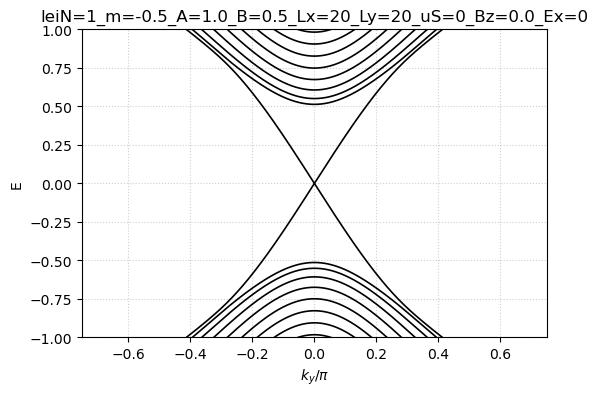

In [34]:
# 中间能带
Bz = 0.00
T_21 = H_hop(B, a, A, xshumu, Nd, Bz)
params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Bz={Bz}_Ex={Ex}"
ks1 = np.linspace(-1*np.pi, 1*np.pi, 1001)

def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 4))

# ==========================================
# 核心修改：使用 plt.plot 替代 plt.scatter，并设置 linewidth
# ==========================================
for i in range(energies1.shape[1]):
    plt.plot(ks1/np.pi, energies1[:, i], color='black', linewidth=1.2)

#plt.ylim(-0.25,0.25)
#plt.xlim(-0.078,0.078)
plt.ylim(-1, 1)
plt.xlim(-0.75, 0.75)
plt.xlabel(r'$k_y/\pi$')
plt.ylabel('E')
plt.title(f'{params_str}')
plt.grid(True, linestyle=':', alpha=0.6)
#save_fig_by_title_1(params_str)
print(leiN)
plt.show()

In [52]:
#保存
params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Ex={Ex}"
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')

save_dir = rf"D:\结果\2026.4.29"
os.makedirs(save_dir, exist_ok=True)

def save_fig_by_title_1(name):
    safe_name = name
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')
    filename = os.path.join(save_dir, safe_name + ".png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"已保存图片: {filename}")


def save_data_to_txt(x_data, y_data, filename, save_dir, header_text="X_Data\tY_Data"):
    """
    通用 txt 数据保存函数
    :param x_data: x 轴数据 (比如 Bz_values)
    :param y_data: y 轴数据 (比如 G_values)
    :param filename: 保存的文件名 (不需要加 .txt 后缀)
    :param save_dir: 保存的文件夹路径
    :param header_text: txt 文件第一行的表头说明
    """
    # 确保文件夹存在
    os.makedirs(save_dir, exist_ok=True)
    
    # 替换文件名中可能导致报错的非法字符
    safe_name = filename
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')
        
    # 拼接完整路径
    filepath = os.path.join(save_dir, safe_name + ".txt")
    
    # 将 x 和 y 拼成两列矩阵
    data_matrix = np.column_stack((x_data, y_data))
    
    # 写入 txt，使用科学计数法保留 8 位小数，以 tab 键分割
    np.savetxt(filepath, data_matrix, fmt='%.8e', delimiter='\t', header=header_text, comments='# ')
    print(f"✅ 数据已成功保存至: {filepath}")

Calculating Bands (Bz=0.008): 100%|██████████| 1001/1001 [00:00<00:00, 10976.78it/s]


已保存图片: D:\结果\2026.4.29\leiN=1_m=-0.5_A=1.0_B=0.5_Lx=20_Ly=20_uS=0_Ex=0.png


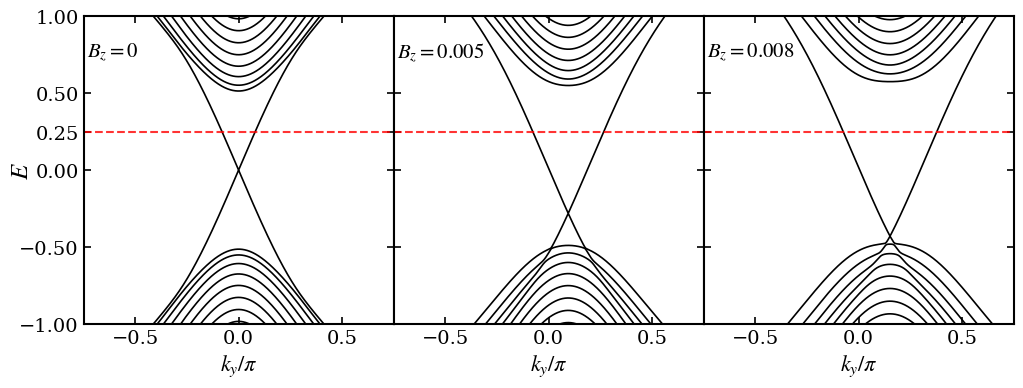

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm

# ==========================================
# 0. PRL 级别全局绘图格式美化设置
# ==========================================
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['mathtext.fontset'] = 'stix'  # 渲染出极其完美的物理公式斜体 (类似 Times New Roman)
mpl.rcParams['axes.linewidth'] = 1.5       # 全局边框加粗
mpl.rcParams['xtick.direction'] = 'in'     # X轴刻度朝内
mpl.rcParams['ytick.direction'] = 'in'     # Y轴刻度朝内
mpl.rcParams['xtick.top'] = True           # 显示上方刻度线
mpl.rcParams['ytick.right'] = True         # 显示右侧刻度线
mpl.rcParams['xtick.major.width'] = 1.2    # X轴刻度线变粗
mpl.rcParams['ytick.major.width'] = 1.2    # Y轴刻度线变粗
mpl.rcParams['xtick.major.size'] = 5       # 刻度线长度
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['font.size'] = 14             # 全局基准字号

# 1. 准备要扫描的 Bz 列表和动量空间
Bz_list = [0, 0.005, 0.008]
ks1 = np.linspace(-1*np.pi, 1*np.pi, 1001)

def Hk(k, H, T):
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

# 2. 创建一个 1行3列 的画布，稍微调整比例使其紧贴后更协调
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 3. 遍历 Bz 列表并分别画在对应的子图上
for idx, Bz in enumerate(Bz_list):
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz)
    energies1 = []
    
    for k in tqdm(ks1, desc=f"Calculating Bands (Bz={Bz})"):
        H_k = Hk(k, H_q, T_21)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)

    energies1 = np.array(energies1)
    ax = axes[idx]
    
    # 画出所有能带
    for i in range(energies1.shape[1]):
        ax.plot(ks1/np.pi, energies1[:, i], color='black', linewidth=1.2)
    
    # 在 E = 0.25 处画一条红色虚线的水平横线
    ax.axhline(y=0.25, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

    # 🎯 将 Bz 标签放置在左上角 (0.05, 0.92 为相对图框的比例坐标)
    ax.text(0.01, 0.92, fr'$B_z = {Bz}$', transform=ax.transAxes, 
            fontsize=15, verticalalignment='top')

    # 设置子图的坐标轴限制
    ax.set_ylim(-1, 1)
    ax.set_xlim(-0.75, 0.75)
    
    # X 轴标签每个图都要有
    ax.set_xlabel(r'$k_y/\pi$', fontsize=16)

    y_ticks = [-1, -0.5, 0, 0.25, 0.5, 1]
    ax.set_yticks(y_ticks)
    
    # 🎯 处理 Y 轴的标注逻辑：只保留最左侧的文字和数字
    if idx == 0:
        ax.set_ylabel(r'$E$', fontsize=18, labelpad=-10)
    else:
        # 隐藏第2和第3个图的 Y 轴数字刻度，但保留刻度线本身 (朝内)
        ax.set_yticklabels([]) 
        
    # 取消网格线，PRL 风格的能带图通常不带虚线网格以保持画面极致干净
    # 但如果你坚决要保留，可以取消下面这行的注释
    # ax.grid(True, linestyle=':', alpha=0.6)

# 🎯 核心修改：让三个子图完全紧贴在一起，间隙为 0
plt.subplots_adjust(wspace=0.0)

# 显示图像
save_fig_by_title_1(params_str)
plt.show()

In [54]:
import numpy as np
from tqdm import tqdm

# 1. 设定要计算的目标能量和磁场列表
E_target = 0.25
Bz_list = [0.0, 0.005, 0.008]

# 为了保证极高的精度，我们可以把 k 点撒得密一点 (例如 5000 个点)
ks_dense = np.linspace(-np.pi, np.pi, 5000)

def Hk(k, H, T):
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

print(f"开始计算 E = {E_target} 时的精确 k_y 值...\n")

for Bz in Bz_list:
    # 重新生成当前 Bz 下的层间跃迁矩阵
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz)
    
    energies = []
    # 计算当前磁场下的所有能带
    for k in ks_dense:
        H_k = Hk(k, H_q, T_21)
        evals = np.linalg.eigvalsh(H_k)
        energies.append(evals)

    energies = np.array(energies)
    
    crossings = []
    
    # 2. 遍历所有能带，寻找与 E=0.25 的交点
    for i in range(energies.shape[1]):
        # 将能带整体减去 0.25，转化为找零点问题
        diff = energies[:, i] - E_target
        
        # 寻找符号发生改变的相邻两个点 (即穿过 0 的地方)
        cross_idx = np.where(np.diff(np.sign(diff)))[0]
        
        for idx in cross_idx:
            # 3. 使用线性插值计算极其精确的 k 值
            k1, k2 = ks_dense[idx], ks_dense[idx+1]
            e1, e2 = diff[idx], diff[idx+1]
            
            k_cross = k1 - e1 * (k2 - k1) / (e2 - e1)
            crossings.append(k_cross)
            
    # 排序交点
    crossings = np.sort(crossings)
    
    # 筛选出负 k 和 正 k
    neg_k = [k for k in crossings if k < 0]
    pos_k = [k for k in crossings if k > 0]
    
    # 打印结果
    print(f"===== Bz = {Bz} =====")
    if len(neg_k) > 0 and len(pos_k) > 0:
        # 选取最靠近中心的两个交点 (对应手性边缘态)
        print(f"负 ky = {neg_k[-1]:.6f}  (即 {neg_k[-1]/np.pi:.6f} π)")
        print(f"正 ky = {pos_k[0]:.6f}  (即 {pos_k[0]/np.pi:.6f} π)\n")
    else:
        print("未在该能量处找到对应的 k 点！\n")

开始计算 E = 0.25 时的精确 k_y 值...

===== Bz = 0.0 =====
负 ky = -0.252680  (即 -0.080431 π)
正 ky = 0.252680  (即 0.080431 π)

===== Bz = 0.005 =====
负 ky = -0.240789  (即 -0.076645 π)
正 ky = 0.837691  (即 0.266645 π)

===== Bz = 0.008 =====
负 ky = -0.234084  (即 -0.074511 π)
正 ky = 1.189128  (即 0.378511 π)

